In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/atilsamancioglu/MachineLearningNotebooks/refs/heads/main/8-fraud_detection.csv')

In [ ]:
df.head() # data düzenli ve scale edilmiş

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [ ]:
df.describe()

,transaction_amount,transaction_risk_score,is_fraud
count,10000.000000,10000.000000,10000.000000
mean,0.976419,-1.003136,0.015400
std,0.725346,0.789194,0.123144
min,-3.370100,-3.952121,0.000000
25%,0.505517,-1.538232,0.000000
50%,0.990240,-0.997064,0.000000
75%,1.461125,-0.466221,0.000000
max,3.487193,1.872543,1.000000


In [ ]:
df.info() #null yok

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_amount      10000 non-null  float64
 1   transaction_risk_score  10000 non-null  float64
 2   is_fraud                10000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


In [ ]:
df.columns

Index(['transaction_amount', 'transaction_risk_score', 'is_fraud'], dtype='object')

In [ ]:
df['is_fraud'].unique()

array([0, 1])

In [ ]:
df['is_fraud'].value_counts() #imbalanced dataset (9846 hayır 154 evet)

,count
is_fraud,
0,9846
1,154


In [ ]:
df.isnull().sum()

,0
transaction_amount,0
transaction_risk_score,0
is_fraud,0


In [ ]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [ ]:
X.head()

,transaction_amount,transaction_risk_score
0,1.879910,-1.485035
1,0.377083,-2.238585
2,1.354312,-2.664638
3,-0.509843,-1.502950
4,0.863561,-1.906364


In [ ]:
y.head()

,is_fraud
0,0
1,0
2,0
3,0
4,0


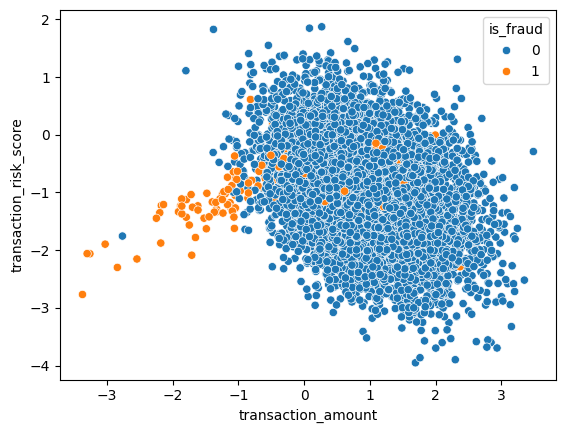

In [ ]:
sns.scatterplot(x=X['transaction_amount'], y=X['transaction_risk_score'], hue=y)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
penalty= ["l1", "l2", "elasticnet"]
c_values = [100, 10, 1.0, 0.1, 0.01]
solver = ["newton-cg","lbfgs", "liblinear", "sag", "saga", "newton-cholesky"]
class_weight = [{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]] #??????

In [ ]:
class_weight#???????

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [ ]:
params=dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)

In [ ]:
import warnings
warnings.filterwarnings("ignore") # bu bana uyarılarını göstermez

In [ ]:
grid.fit(X_train, y_train) # çok uzun sürecek bu işlem her şeyi tek tek deneyecek

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga', 'newton-cholesky']},
             scoring='accuracy')

In [ ]:
y_pred = grid.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
print("score: ",accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))

score:  0.99
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500

confusion matrix: 
 [[2459   22]
 [   3   16]]


In [ ]:
grid.best_params_ #önceki datalardan baya farklı şeyler kullanmış

{'C': 0.01,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l2',
 'solver': 'newton-cg'}

# **ROC** , **AUC**
The ROC Curve is a graphical representation of a classification model’s performance across different threshold values. It plots the True Positive Rate (Recall) on the Y-axis against the False Positive Rate (1 - Specificity) on the X-axis. • A model that perfectly distinguishes between classes has a curve that reaches the top-left corner. • The closer the curve is to the top-left, the better the model. • The area under the ROC curve (AUC) quantifies this performance: • AUC = 1 → perfect classifier • AUC = 0.5 → random guessing

ROC is especially useful for imbalanced datasets, as it evaluates the model independent of class distribution or threshold.

AUC = area under the curve
------------------------
ROC

1.Characteristic Curve

Bu bir eğri/grafik.

X ekseninde: False Positive Rate (FPR) yani "yanlış alarm oranı"

Y ekseninde: True Positive Rate (TPR) yani "doğru yakalama oranı" (hassasiyet/sensitivity)

👉 Yani ROC eğrisi, modelin farklı eşik (threshold) değerlerinde ne kadar doğru pozitifleri yakalayabildiğini, aynı anda ne kadar yanlış pozitif ürettiğini gösterir.

In [ ]:
# probabilityleri veriyor
model_prob = grid.predict_proba(X_test)

In [ ]:
model_prob

array([[0.99586436, 0.00413564],
       [0.85287009, 0.14712991],
       [0.952308  , 0.047692  ],
       ...,
       [0.98898975, 0.01101025],
       [0.98454137, 0.01545863],
       [0.99758734, 0.00241266]])

In [ ]:
model_prob = model_prob[:,1] #sağ tarafı alıyor
# probabilities for the positive (fraud) class

In [ ]:
model_prob

array([0.00413564, 0.14712991, 0.047692  , ..., 0.01101025, 0.01545863,
       0.00241266])

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
model_auc = roc_auc_score(y_test, model_prob)

In [ ]:
model_auc

np.float64(0.7392898371029116)

In [ ]:
# model false positive rate
# model true positive rate
model_fpr, model_tpr, model_thresholds = roc_curve(y_test, model_prob)

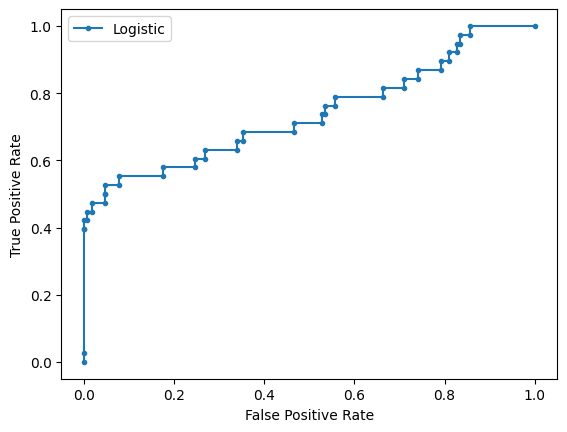

In [ ]:
plt.plot(model_fpr, model_tpr, marker = ".", label="Logistic")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

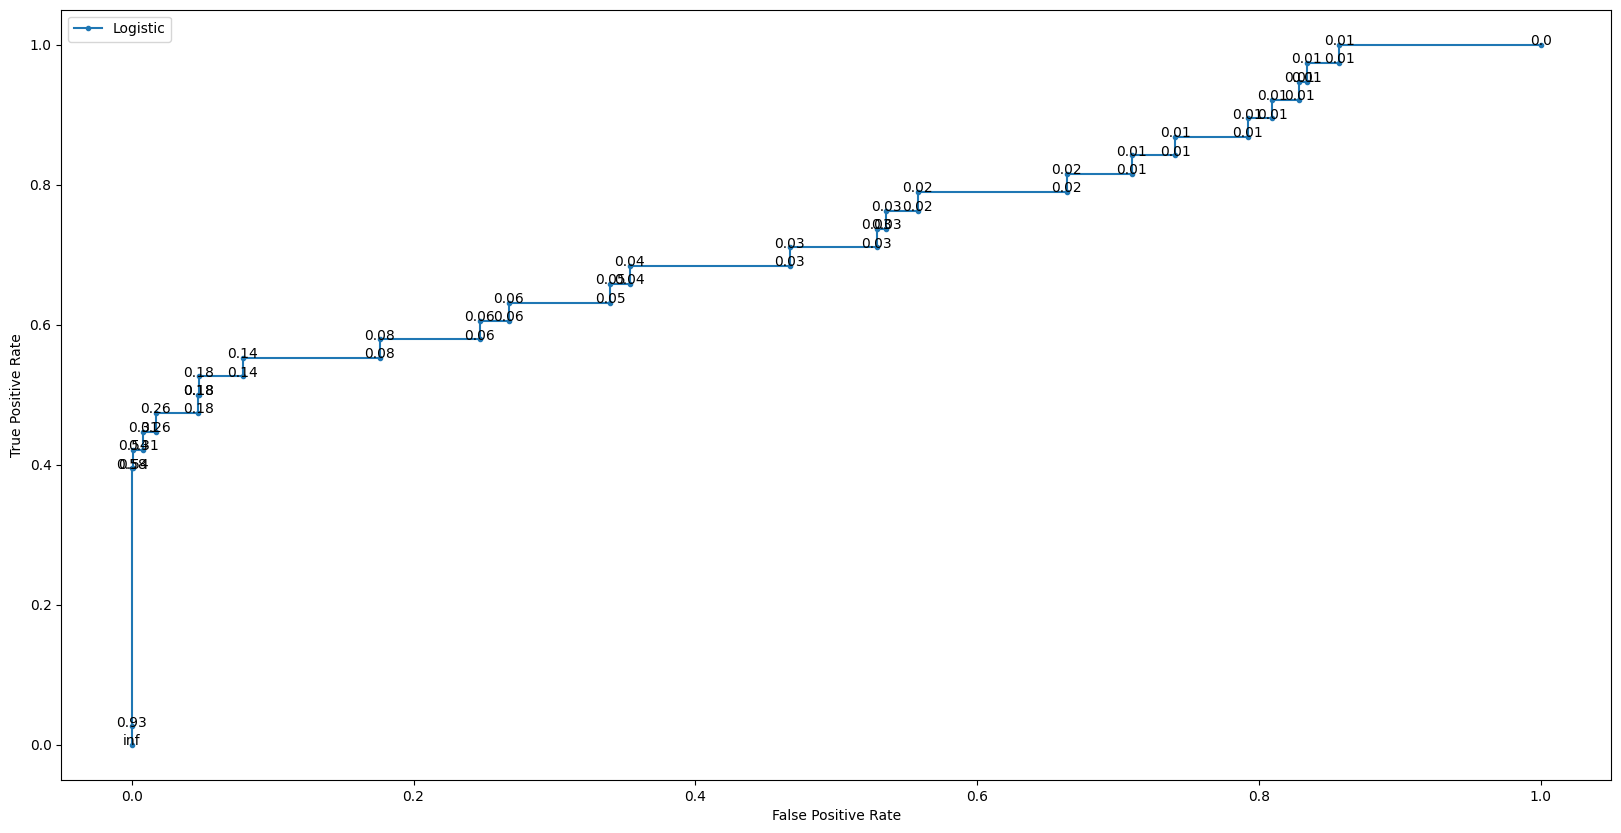

In [ ]:
fig, ax = plt.subplots(figsize = (20,10))

ax.plot(model_fpr, model_tpr, marker = ".", label="Logistic")

for fpr, tpr, thresh in zip(model_fpr, model_tpr, model_thresholds):
    ax.annotate(f"{np.round(thresh, 2)}", (fpr, tpr), ha="center")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

#yukarıdaki grafiğin aynısı ancak her bir noktada treshholdu gösteriyor

In [ ]:
custom_threshold = 0.5 # 0.2 denedi ve aynı zamanda diğer değerler de denendi en mantıklısı 0.5 yapmak oldu

y_pred_custom = (model_prob >= custom_threshold).astype(int)

print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom, y_test))

[[2459   22]
 [   3   16]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500



In [ ]:
y_pred_custom

array([0, 0, 0, ..., 0, 0, 0])